In [1]:
import os, sys, pickle
%pylab inline
from importlib import reload
import pandas as pd
plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 3)
from tqdm import tqdm
from copy import deepcopy
import pickle
from collections import Counter

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
git_path = os.getenv("GIT")
proj_path = os.path.join(git_path, "glom-io-transform-release")
sys.path.append(proj_path)
os.chdir(proj_path + "/model-fitting")
os.getcwd()
os.environ["GLOM_IO"] = proj_path
os.environ["GLOM_IO_DATA"] = proj_path + "/data"

In [4]:
from odours import odours
import driver; reload(driver)
from driver import RunResults

In [24]:
import layout; reload(layout)
import results; reload(results)

base = results.BaseContext(fits_root = proj_path + "/model-fitting/fits", models_dir=proj_path + "/model-fitting",
                          standardization="separate", normalization="odour_std", center=True)
trials = base.split("odours", "outclass", "max")


Loading pre-saved model results from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/odours_outclass_max.p.
Loaded models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/odours_outclass_max.p.


In [6]:
model = trials.model("DiagOnlyInh")
metric = "ratio"
df = model.report(metric, extra_fields=["outclass"]).sort_values(by=["outclass"])
df

,seed,λ,outclass,ratio
255,42,31.622777,Acid,0.397708
163,27,3.162278,Acid,0.387322
235,39,10.000000,Acid,0.252737
285,47,10.000000,Acid,0.196100
32,5,10.000000,Acid,0.131941
...,...,...,...,...
147,24,10000.000000,Ketone,0.265090
70,11,31.622777,Ketone,0.449102
245,40,10000.000000,Ketone,0.459101
87,14,10000.000000,Ketone,0.244240


In [8]:
# Get the distribution of how close the model correlations are to the output
extra_fields = {"outclass":"Ketone"}
vals = []
for seeds in range(50):
    for trains in range(10):
        res = model.extract(seed=seeds, train=trains, metric=metric, **extra_fields)
        corrs = res.vld_corrs
        in_out = np.mean((corrs["Cin"] - corrs["Cstar"])**2)**0.5
        est_out=np.mean((corrs["Cest"] - corrs["Cstar"])**2)**0.5
        vals.append(est_out/in_out)
        
        

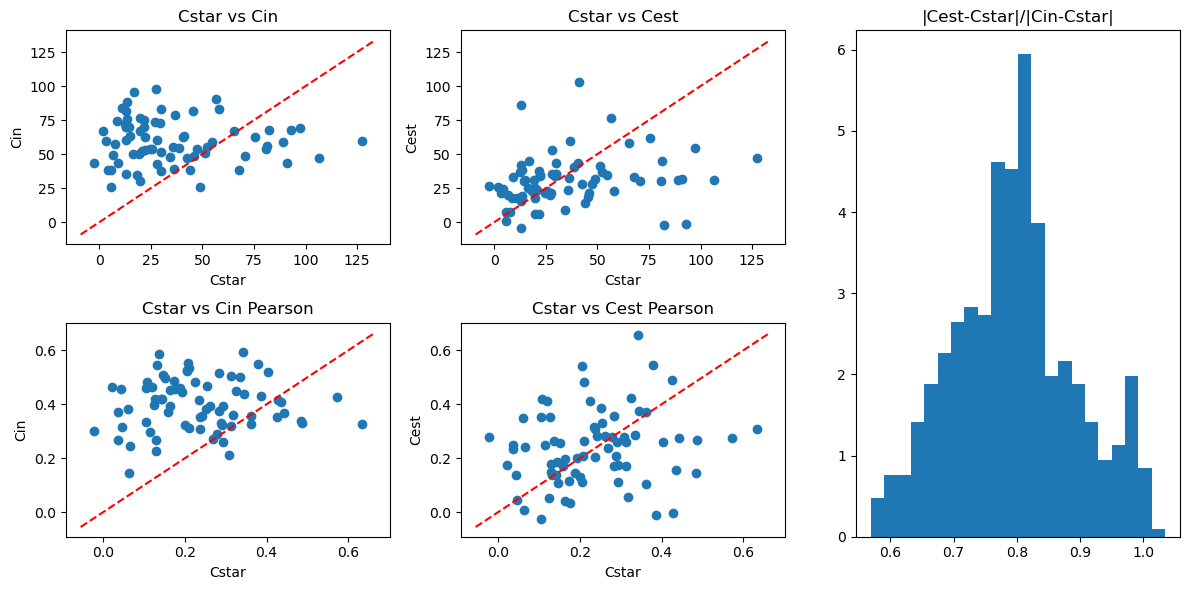

In [9]:
from matplotlib.gridspec import GridSpec
res = model.extract(seed=0, train=0, metric=metric, **extra_fields)
covs = res.vld
corrs = res.vld_corrs
 
is_square = covs.Cin.shape[0] == covs.Cin.shape[1]
fig = plt.figure(figsize=(12, 6))
if is_square:
    gs = GridSpec(2,4)
    # The first three columns of hte first row are Cin, Cstar, Cest
    # Those of the second row are the corresponding pearson correlations
    for i, ds in enumerate(["Cin", "Cstar", "Cest"]):
        ax = fig.add_subplot(gs[0, i])
        ax.imshow(getattr(covs, ds))
        ax.set_title(ds)
        ax = fig.add_subplot(gs[1, i])
        ax.imshow(corrs[ds], vmin=0, vmax=1, cmap="bwr")
        ax.set_title(f"{ds} Pearson")
else:
    # Plot as a scatter of Cstar vs Cin, Cstar vs Cest
    gs = GridSpec(2, 3)
    for i, ds in enumerate(["Cin", "Cest"]):
        ax = fig.add_subplot(gs[0, i])
        ax.scatter(covs.Cstar.flatten(),getattr(covs, ds).flatten())
        ax.set_title(f"Cstar vs {ds}")
        ax.set_xlabel("Cstar")
        ax.set_ylabel(ds)
        xl = ax.get_xlim()
        ax.plot(xl, xl, ls="--", color="r")
        ax = fig.add_subplot(gs[1, i])
        ax.scatter(corrs["Cstar"].flatten(), corrs[ds].flatten())
        ax.set_title(f"Cstar vs {ds} Pearson")
        ax.set_xlabel("Cstar")
        ax.set_ylabel(f"{ds}")
        xl = ax.get_xlim()
        ax.plot(xl, xl, ls="--", color="r")
 
    
ax = fig.add_subplot(gs[:, -1])
ax.hist(vals, bins=int(np.sqrt(len(vals))), density=True)
ax.set_title("|Cest-Cstar|/|Cin-Cstar|")
tight_layout()

## Figure for the Paper

In [169]:
def vld_fun_ratio(vld):
    in_out = np.mean((vld.Cin - vld.Cstar)**2)**0.5
    est_out=np.mean((vld.Cest - vld.Cstar)**2)**0.5
    return in_out, est_out 

def vld_fun_corr(corrs):
    in_out = np.mean((corrs["Cin"] - corrs["Cstar"])**2)**0.5
    est_out=np.mean((corrs["Cest"] - corrs["Cstar"])**2)**0.5
    return in_out, est_out

def compute_corr_energ_(C):
    # If C is a square matrix, use the off-diagonal elements to compute the energy
    if C.shape[0] == C.shape[1]:
        total_energy = np.sum(C**2) - np.sum(np.diag(C)**2)
        n_elements = C.shape[0] * (C.shape[0] - 1)
        return total_energy / n_elements
    else:
        # If C is not square, compute the energy using all elements
        return np.mean(C**2)
        
def vld_fun_corr_energy(corrs):
    [in_, out_, est_] = [compute_corr_energ_(corrs[key]) for key in ["Cin", "Cstar", "Cest"]]
    return in_, out_, est_

In [120]:
reload(results)
selection_metric = "ratio"
splits = [
    ("trials", "random", "max"),
    ("odours", "random", "max"),
    ("odours", "inclass", "max"),
    ("odours", "outclass", "max")
] 
base = results.BaseContext(fits_root = proj_path + "/model-fitting/fits", models_dir=proj_path + "/model-fitting",
                          standardization="separate", normalization="odour_std", center=True)

which_models = ["Diag", "DiagOnlyInh", "Free", "FreeLat"]
# Import cartesiaon product
from itertools import product
selection_metric = "ratio"
records = []
for split_name in splits:
    split = base.split(*split_name)
    for model_name in which_models:
        model   = split.model(model_name)
        n_train = len(model.df["ref"].unique())
        #report  = model.report(metric=selection_metric, extra_fields = ["outclass"] if "outclass" in split_name else [])     
        n_seeds = len(model.df["seed"].unique())
        # I wanted to use report to get the best parameter values, but extract already does that.
        # All in need to know is whether to include the outclass
        outclasses = model.df["outclass"].unique()
        iterable = product(range(n_seeds), range(n_train), outclasses)
        for seed, train, outclass in tqdm(iterable, total=n_seeds*n_train*len(outclasses)):
            extra_fields = {"outclass":outclass} if "outclass" in split_name else {}
            #print(f"{split_name}, {model_name}, seed={seed}, train={train}, outclass={outclass}")
            res = model.extract(seed=seed, train=train, metric=selection_metric, **extra_fields)
            cov_in_out, cov_est_out = vld_fun_ratio(res.vld)
            corr_in_out, corr_est_out = vld_fun_corr(res.vld_corrs)
            corr_en_in, corr_en_out, corr_en_est = vld_fun_corr_energy(res.vld_corrs)
            records.append({
                "sampler": split_name[0],
                "mode": split_name[1],
                "n_od_train": split_name[2],
                "model": model_name,
                "seed": seed,
                "train": train,
                "outclass": outclass,
                "cov_in_out": cov_in_out,
                "cov_est_out": cov_est_out,
                "corr_in_out": corr_in_out,
                "corr_est_out": corr_est_out,
                "corr_en_in": corr_en_in,
                "corr_en_out": corr_en_out,
                "corr_en_est": corr_en_est
            })
df = pd.DataFrame(records)



Loaded pre-saved model from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/trials_random_max.p.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:05<00:00, 83.40it/s]


Loaded pre-saved model from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/odours_random_max.p.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:05<00:00, 92.94it/s]


Loaded pre-saved model from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/odours_inclass_max.p.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:05<00:00, 86.14it/s]


Loaded pre-saved model from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/odours_outclass_max.p.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [01:46<00:00, 28.28it/s]


In [121]:
# Save the df to disk
with open(proj_path + "/model-fitting/generalization_results.pkl", "wb") as f:
    pickle.dump(df, f)

In [122]:
df.head()

,sampler,mode,n_od_train,model,seed,train,outclass,cov_in_out,cov_est_out,corr_in_out,corr_est_out,corr_en_in,corr_en_out,corr_en_est
0,trials,random,max,Diag,0,0,None,55.804779,27.201186,0.304090,0.177390,0.268415,0.079588,0.108356
1,trials,random,max,Diag,0,1,None,56.364182,28.367374,0.304578,0.179064,0.268415,0.080531,0.108356
2,trials,random,max,Diag,0,2,None,56.652894,28.392783,0.306596,0.179960,0.268415,0.078880,0.108356
3,trials,random,max,Diag,0,3,None,56.039460,27.737512,0.305300,0.178228,0.268415,0.080032,0.108356
4,trials,random,max,Diag,0,4,None,55.703823,27.539079,0.305495,0.179817,0.268415,0.080832,0.108356


In [123]:
df["model"].unique()

array(['Diag', 'DiagOnlyInh', 'Free', 'FreeLat'], dtype=object)

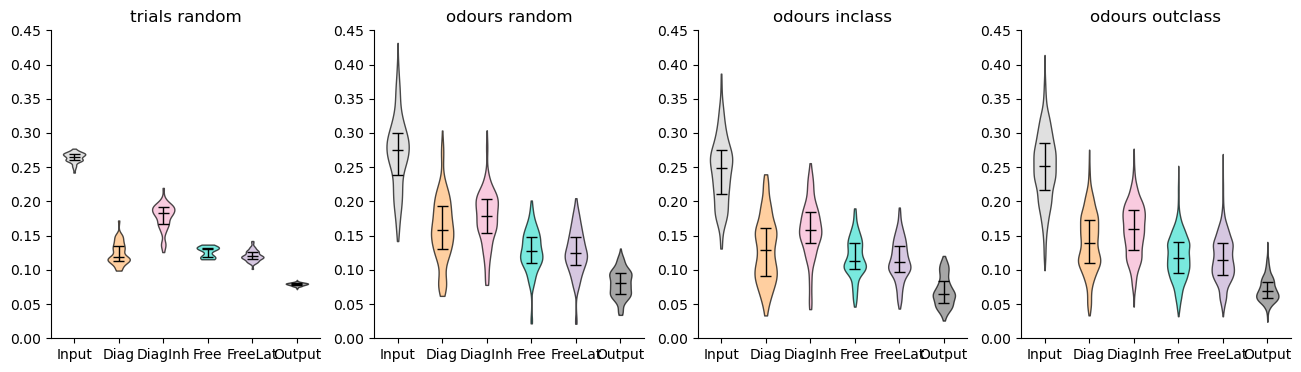

In [125]:
import figures; reload(figures)
from figures import ViolinPlotData, violin_plots, scatter_plot
import proc_fit_models as pfm; reload(pfm)
prefix = "corr_en"
assert prefix in ["cov", "corr", "corr_en"], "prefix must be one of 'cov', 'corr', or 'corr_en'"
nr, nc = 1, 4
fig, ax = plt.subplots(nrows=nr, ncols=nc, figsize=(4 * nc, 4 * nr))
split_descr = {"trials": ("trials", "random"),
               "odours_random,": ("odours", "random"),
               "odours_inclass": ("odours", "inclass"),
               "odours_outclass": ("odours", "outclass")}
order = ["trials", "odours_random,", "odours_inclass", "odours_outclass"]
model_names = which_models 
model_labs = {"Diag": "Diag",
              "DiagOnlyInh": "DiagInh",
              "Free": "Free",
              "FreeLat": "FreeLat"}
cols = ["Gray"] + [pfm.model_color(m) for m in model_names] 
for i, (axi, split_name) in enumerate(zip(ax.flatten(), order)):
    sampler, mode = split_descr[split_name]
    split_mask = (df["sampler"] == sampler) & (df["mode"] == mode) 
    if prefix in ["cov", "corr"]:
        in_out       = df[split_mask & (df['model']=="Diag")][f"{prefix}_in_out"].values
        models_est_out = [df[split_mask & (df['model']==m)][f"{prefix}_est_out"].values for m in model_names]
        axi = violin_plots(axi, [ViolinPlotData(in_out, "LightGray", "Input")] 
                           + [ViolinPlotData(models_est_out[i], pfm.model_color(model_names[i]), model_labs[model_names[i]]) for i in range(len(model_names))])
    else:
        en_in       = df[split_mask & (df['model']=="Diag")][f"{prefix}_in"].values
        en_out      = df[split_mask & (df['model']=="Diag")][f"{prefix}_out"].values
        en_est_models = [df[split_mask & (df['model']==m)][f"{prefix}_est"].values for m in model_names]
        axi = violin_plots(axi, [ViolinPlotData(en_in, "LightGray", "Input")]
                           + [ViolinPlotData(en_est_models[i], pfm.model_color(model_names[i]), model_labs[model_names[i]]) for i in range(len(model_names))]
                           + [ViolinPlotData(en_out, "Gray", "Output")])
        axi.set_ylim((0, 0.45))
    axi.set_title(f"{sampler} {mode}")
    #i >0 and axi.set_ylim((0, 0.5) if prefix=="corr" else (0, 80))
    [axi.spines[spine].set_visible(False) for spine in ['top', 'right']]

Using cached models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/trials_random_max.p.
Using cached models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/odours_random_max.p.
Using cached models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/odours_inclass_max.p.
Using cached models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/odours_outclass_max.p.


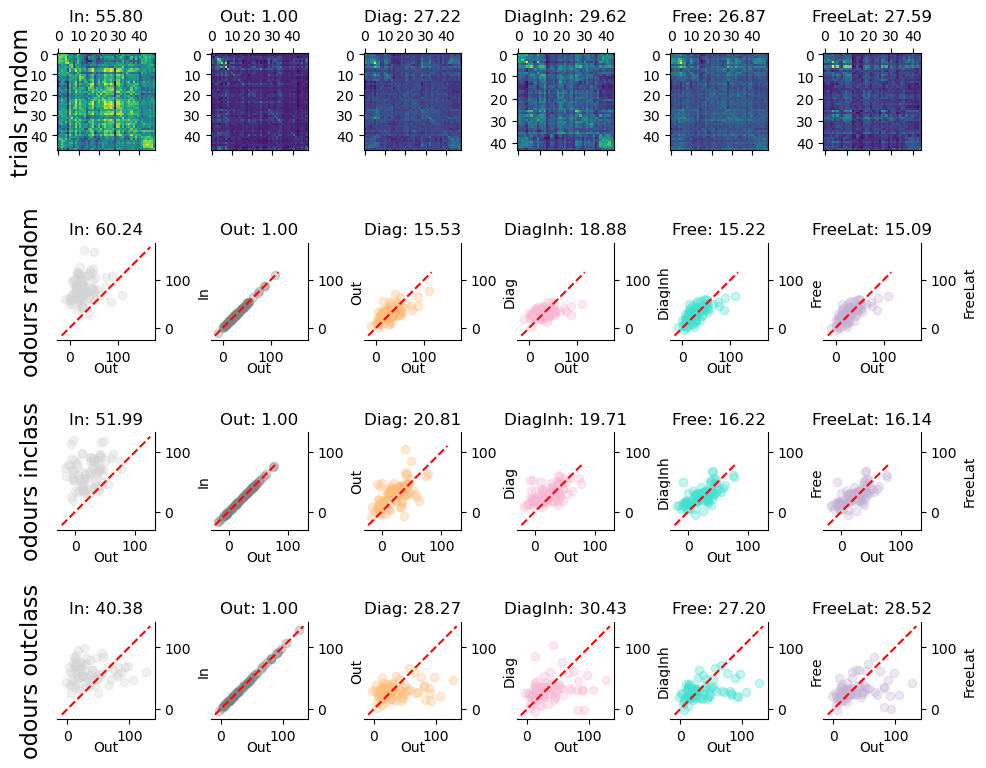

In [41]:
reload(figures)
from figures import scatter_plot
fig, ax = plt.subplots(nrows=4, ncols=len(which_models)+2, figsize=(10, 8))
vmin = {"cov": None, "corr": 0, "corr_en": 0}
vmax = {"cov": None, "corr": 1, "corr_en": 1}
cmap = {"cov": "viridis", "corr": "bwr", "corr_en": "bwr"}
ttls = ["In", "Out"] + [model_labs[m] for m in which_models]
append_to_title = lambda ax, s: ax.set_title(ax.get_title() + s)
prepend_to_title = lambda ax, s: ax.set_title(s + ax.get_title())
for i, split_name in enumerate(order):
    descr = split_descr[split_name]
    split = base.split(sampler=descr[0], mode=descr[1], n_od_train="max")
    extra_fields = {"outclass":"Ketone"} if "outclass" in split_name else {}
    for j, name in enumerate(which_models):
        model = split.model(name)
        res = model.extract(seed=0, train=0, metric=selection_metric, **extra_fields)
        covs = {k: getattr(res.vld, k) for k in ["Cin", "Cstar", "Cest"]}
        corrs = res.vld_corrs
        cov_in_out, cov_est_out = vld_fun_ratio(res.vld)
        corr_in_out, corr_est_out = vld_fun_corr(res.vld_corrs)
        corr_en_in, corr_en_out, corr_en_est = vld_fun_corr_energy(res.vld_corrs)

        vals = covs if prefix == "cov" else corrs
        matshow_kwargs = {"vmin": vmin[prefix], "vmax": vmax[prefix], "cmap": cmap[prefix]} 
        plot_fun = lambda ax, k, ylab, c: (ax.matshow(vals[k], **matshow_kwargs), ax.set_xticks(np.arange(0,50,10)), ax.set_yticks(np.arange(0,50,10))) if i == 0 else scatter_plot(ax, vals["Cstar"], vals[k], "Out", ylab, c)

        in_val  = {"cov":cov_in_out, "corr":corr_in_out, "corr_en":corr_en_in}[prefix]
        est_val = {"cov":cov_est_out, "corr":corr_est_out, "corr_en":corr_en_est}[prefix]
        out_val = {"cov":1., "corr":1., "corr_en":corr_en_out}[prefix]

        if name == "Diag":
            plot_fun(ax[i,0], "Cin", "In", "LightGray")
            ax[i,0].set_title(f"In: {in_val:.2f}")
            plot_fun(ax[i,1], "Cstar", "Out", "Gray")
            ax[i,1].set_title(f"Out: {out_val:.2f}")

        plot_fun(ax[i,2+j], "Cest", ttls[j+2], pfm.model_color(name))
        ax[i,2+j].set_title(f"{ttls[j+2]}: {est_val:.2f}")
    if i > 0:
        # Share the x and y lims with the first plot in the row
        for j in range(2 + len(which_models)):
            ax[i,j].set_xlim(ax[i,0].get_xlim())
            ax[i,j].set_ylim(ax[i,0].get_ylim())
            ax[i,j].set_aspect('equal')
            # Turn top and right spines off
            [ax[i,j].spines[spine].set_visible(False) for spine in ['top', 'left']]

    # Put the split description on the left of the row
    ax[i,0].text(-0.25 + 0.1*(i>0), 0.5, f"{descr[0]} {descr[1]}", va='center', ha='right', 
                fontsize=16, transform=ax[i,0].transAxes, rotation=90)
tight_layout(w_pad=0, h_pad=0)


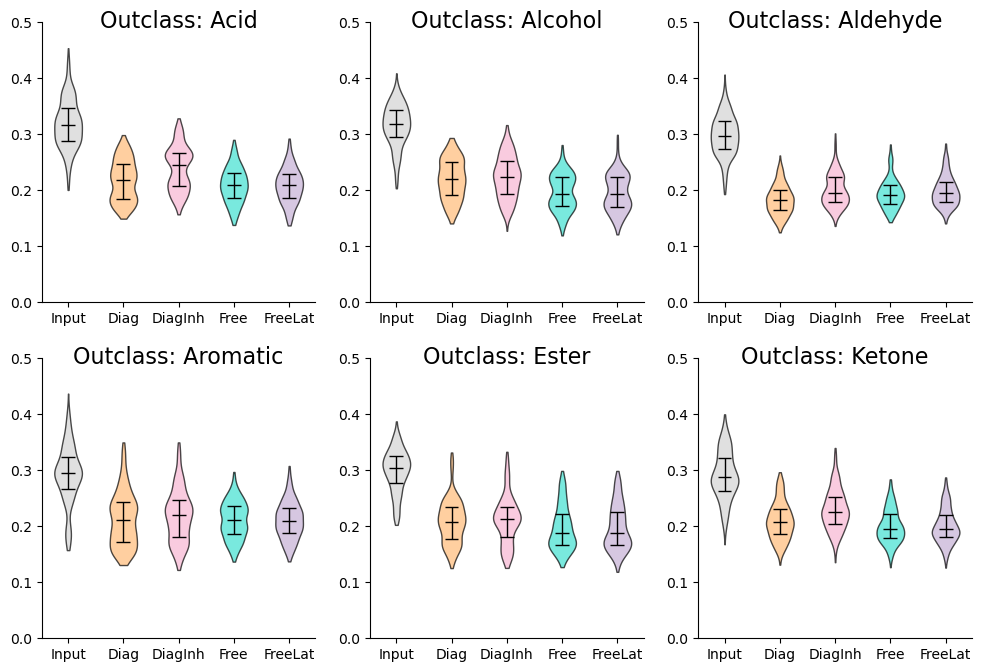

In [180]:
# Now just look at outclass, by outclass
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))
outclasses = sorted(df[df.outclass.notnull()]["outclass"].unique())
for i, (axi, outclass) in enumerate(zip(ax.flatten(), outclasses)):
    split_mask = (df["sampler"] == "odours") & (df["mode"] == "outclass") & (df["outclass"] == outclass)

    if prefix in ["cov", "corr"]:
        in_out       = df[split_mask & (df['model']=="Diag")][f"{prefix}_in_out"].values
        models_est_out = [df[split_mask & (df['model']==m)][f"{prefix}_est_out"].values for m in model_names]
        axi = violin_plots([ViolinPlotData(in_out, "LightGray", "Input")] + [ViolinPlotData(est_out, pfm.model_color(m), model_labs[m]) for est_out, m in zip(models_est_out, model_names)])
    else:
        en_in       = df[split_mask & (df['model']=="Diag")][f"{prefix}_in"].values
        en_out      = df[split_mask & (df['model']=="Diag")][f"{prefix}_out"].values
        en_models   = [df[split_mask & (df['model']==m)][f"{prefix}_est"].values for m in model_names]
        axi = violin_plots([ViolinPlotData(en_in, "LightGray", "Input")] + [ViolinPlotData(est, pfm.model_color(m), model_labs[m]) for est, m in zip(en_models, model_names)] + [ViolinPlotData(en_out, "Gray", "Output")])
        #axi.set_ylim((0, 0.45))

    axi.set_title(f"Outclass: {outclass}", fontsize=16, y=0.95)
    axi.set_ylim((0, 0.5) if prefix in["corr", "corr_en"] else (0, 80))
    [axi.spines[spine].set_visible(False) for spine in ['top', 'right']]

Loaded models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/odours_outclass_max.p.


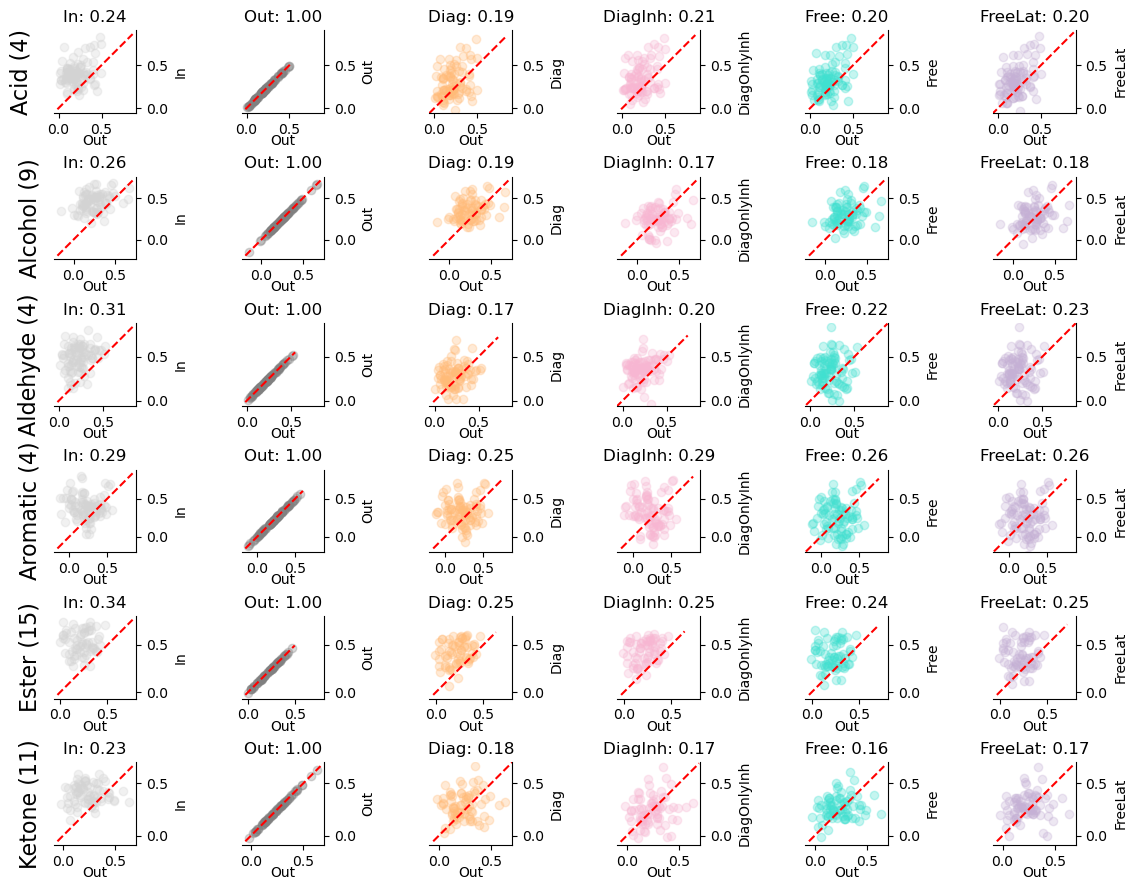

In [181]:
reload(results)
class_counts = Counter(odours.classes)
base = results.BaseContext(fits_root = proj_path + "/model-fitting/fits", models_dir=proj_path + "/model-fitting",
                          standardization="separate", normalization="odour_std", center=True)
fig, ax = plt.subplots(nrows=6, ncols=2+len(which_models), figsize=(12, 9))
for i, outclass in enumerate(outclasses): 
    split = base.split(sampler="odours", mode="outclass", n_od_train="max")
    extra_fields = {"outclass": outclass}
    for j, name in enumerate(which_models):
        model = split.model(name)
        res = model.extract(seed=0, train=0, metric=selection_metric, **extra_fields)
        covs = {k: getattr(res.vld, k) for k in ["Cin", "Cstar", "Cest"]}
        corrs = res.vld_corrs
        cov_in_out, cov_est_out = vld_fun_ratio(res.vld)
        corr_in_out, corr_est_out = vld_fun_corr(res.vld_corrs)
        corr_en_in, corr_en_out, corr_en_est = vld_fun_corr_energy(res.vld_corrs)
 
        vals = covs if prefix == "cov" else corrs
        plot_fun = lambda ax, k, ylab, c: scatter_plot(ax, vals["Cstar"], vals[k], "Out", ylab, c)

        in_val = {"cov":cov_in_out, "corr":corr_in_out, "corr_en":corr_en_in}[prefix]
        est_val = {"cov":cov_est_out, "corr":corr_est_out, "corr_en":corr_en_est}[prefix]
        out_val = {"cov":1., "corr":1., "corr_en":corr_en_out}[prefix]
 
        if name == "Diag":
            plot_fun(ax[i,0], "Cin", "In", "LightGray")
            append_to_title(ax[i,0], f": {in_val:.2f}")
            plot_fun(ax[i,1], "Cstar", "Out", "Gray")
            append_to_title(ax[i,1], f": {out_val:.2f}")
            plot_fun(ax[i,2], "Cest", "Diag", pfm.model_color("Diag"))
            append_to_title(ax[i,2], f": {est_val:.2f}")
        else:
            plot_fun(ax[i,2+j], "Cest", name, pfm.model_color(name))
            append_to_title(ax[i,2+j], f": {est_val:.2f}")
    
    [prepend_to_title(axi, ttl) for axi, ttl in zip(ax[i,:], ttls)]

    # Share the x and y lims with the first plot in the row
    for j in range(2 + len(which_models)):
        ax[i,j].set_xlim(ax[i,0].get_xlim())
        ax[i,j].set_ylim(ax[i,0].get_ylim())
        ax[i,j].set_aspect('equal')
        # Turn top and right spines off
        [ax[i,j].spines[spine].set_visible(False) for spine in ['top', 'left']]

    # Put the split description on the left of the row
    ax[i,0].text(-0.25 + 0.1*(i>0), 0.5, f"{outclass} ({class_counts[outclass]})", va='center', ha='right', 
                 fontsize=16, transform=ax[i,0].transAxes, rotation=90)
tight_layout(w_pad=0, h_pad=0.5)

# Compare Diag and DiagInh
These two models seem to give very similar performance on covariance, but quite different in terms of correlation. Let's understand why.

In [181]:
import layout; reload(layout)
import results; reload(results)
base = results.BaseContext(fits_root = proj_path + "/model-fitting/fits", models_dir=proj_path + "/model-fitting",
                          standardization="separate", normalization="odour_std", center=True)
split = base.split(sampler="trials", mode="random", n_od_train="max")

Loaded pre-saved model from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/trials_random_max.p.


In [195]:
from matplotlib.gridspec import GridSpec
def plot_comparison(models):
    n_mods = len(models)
    model_names = models.keys()
    fig = plt.figure(figsize=(4 * (2 + n_mods + 2), 8))
    gs = GridSpec(2, 2 + n_mods + 2)
    records = [] 
    ax_params = fig.add_subplot(gs[:,-3:])
    ax_cstar = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[1,0])]
    for i, (name, m) in enumerate(models.items()):
        ax = [fig.add_subplot(gs[0, i+1]), fig.add_subplot(gs[1, i+1])]
        if i == 0:
            # In the first row, do a matshow of Cstar, then of Cest (on the same scale), then a scatter plot of Cstar vs Cest
            vmin, vmax = percentile(m.vld.Cstar, [1, 99])
            ax_cstar[0].matshow(m.vld.Cstar, vmin=vmin, vmax=vmax, cmap="Spectral_r")
            ax_cstar[0].set_title("Cstar")
            ax_cstar[1].matshow(m.vld_corrs["Cstar"], vmin=0, vmax=1, cmap="bwr")
            ax_cstar[1].set_title("Rstar")
        
        ax[0].matshow(m.vld.Cest, vmin=vmin, vmax=vmax, cmap="Spectral_r")
        ax[0].set_title(f"Cest ({name})") 
        ratio = np.mean((m.vld.Cest - m.vld.Cstar)**2)**0.5 / np.mean((m.vld.Cin - m.vld.Cstar)**2)**0.5
    
        ax[1].matshow(m.vld_corrs["Cest"], vmin=0, vmax=1, cmap="bwr")
        ax[1].set_title(f"Rest ({name})")

        ax_params.plot(m.params["p_final"], label=name, color=pfm.model_color(name))    
        ax_params.set_title("Final Parameters")

        corr_energy = compute_corr_energ_(m.vld_corrs["Cest"])
        records.append({"name": name, "ratio": ratio, "corr_energy": corr_energy})
    ax_params.legend()

    return pd.DataFrame(records)

,name,ratio,corr_energy
0,Diag,0.552809,0.134753
1,DiagOnlyInh,0.562031,0.184442


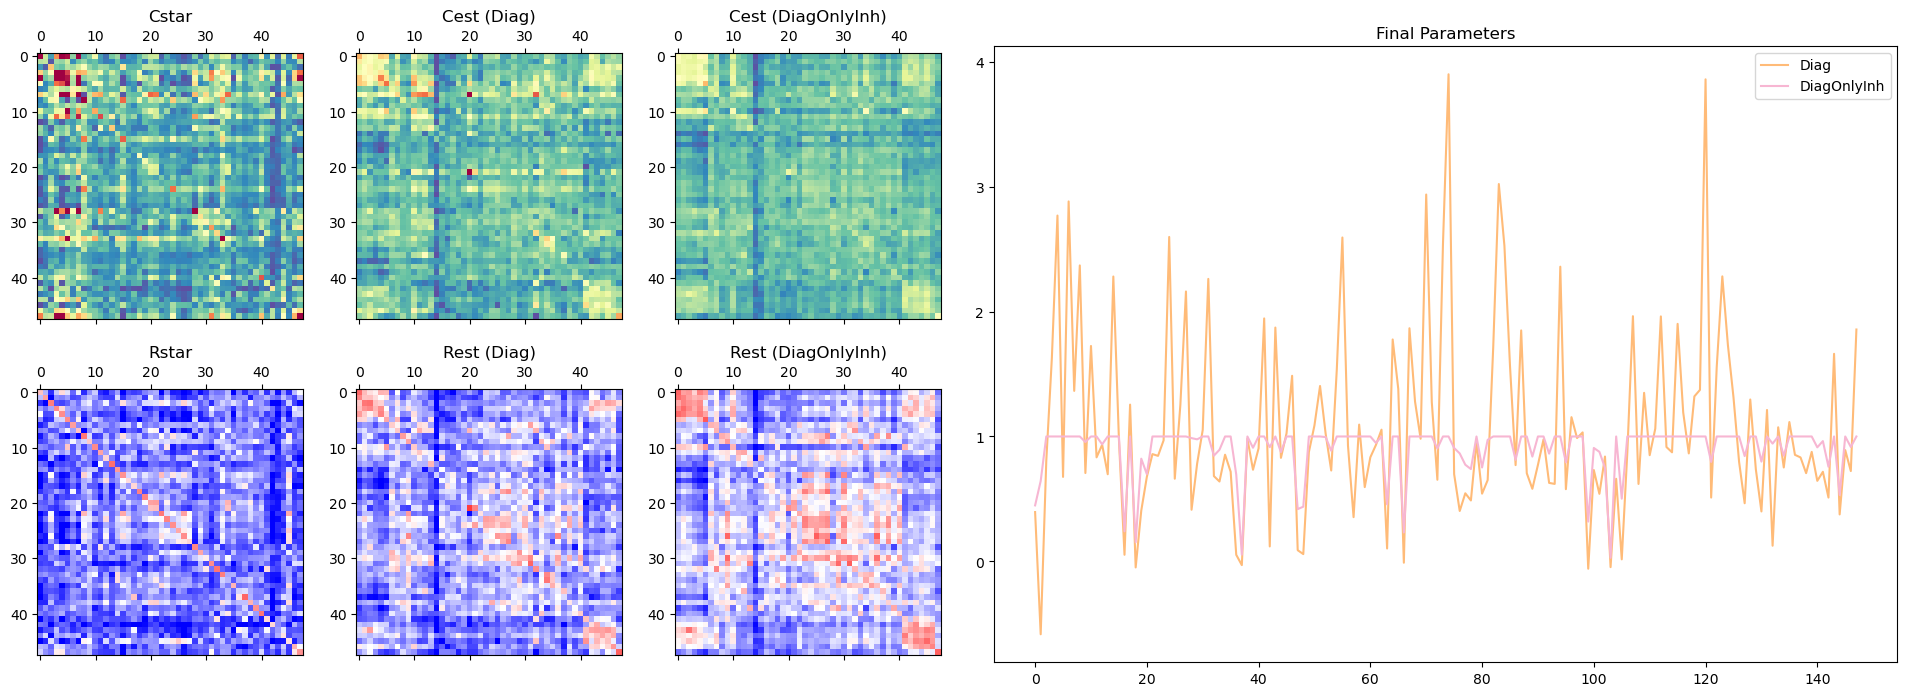

In [202]:
seed = 5
selection_metric = "ratio"
m_diag = split.model("Diag").extract(seed=seed, train=0, metric=selection_metric, with_params = True)
m_diag_inh = split.model("DiagOnlyInh").extract(seed=seed, train=0, metric=selection_metric, with_params=True)
plot_comparison({"Diag": m_diag, "DiagOnlyInh": m_diag_inh})

In [186]:
m_diag.params["p_final"]

array([-0.38404705, -0.08829362, -0.54770104,  1.62729403,  2.27984942,
        0.6464051 ,  1.47466499,  2.19037664,  1.90205126, -0.47797735,
        1.53477308,  2.67425601,  0.86229088,  0.60029507,  4.41122782,
        0.86946987,  0.84068145,  0.83348912, -0.33888147,  0.2909199 ,
        0.91189055,  0.603276  ,  1.16674892,  1.48084031,  2.90353918,
        2.0670945 ,  2.5380153 ,  0.42771528, -0.17676169, -0.64410843,
        2.03500555,  1.7726282 ,  1.07859224,  0.70971945,  0.79224608,
        0.70841126, -0.24267555, -0.24228049,  0.99090886,  0.72978128,
        2.24341992,  2.90050473, -0.44517455,  3.63068347,  3.21335273,
        0.83306281,  1.35419076, -0.9496384 , -0.51776997, -0.52089633,
        1.02108425,  1.523811  ,  4.01043562,  1.28765264,  1.3202471 ,
        2.20598915, -0.4011835 , -0.87088751,  0.72170472, -2.09525413,
        1.56985491,  4.44423623,  1.29747582,  0.63814097, -1.02272098,
        0.67851268, -0.1641309 ,  1.11718032, -0.47563597,  1.75